In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Visualise mutation positions

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import os

from common import set_theme, add_sample_names
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation
from synbio_morpher.utils.results.analytics.naming import get_true_interaction_cols

PALETTE = 'viridis'

set_theme()

top_write_dir = os.path.join('figures', '04_mutations')

# Load data

In [34]:
fn_og = '../data/raw/summarise_simulation/2024_11_27_145142/tabulated_mutation_info.csv'
fn_resim = '../notebooks/data/simulate_circuits/2026_01_12__18_50_13/analytics.json'
data = pd.read_csv(fn_og)
df_resim = pd.read_json(fn_resim).drop(columns='RMSE')
df_resim = df_resim.explode(df_resim.columns.to_list()).reset_index(drop=True)
cols_resim = list(df_resim.columns)

names_species_input = data['sample_name'].unique()
n_species_input = len(names_species_input)
n_species_total = int(len(df_resim) / len(data) * n_species_input)

df_resim = add_sample_names(df_resim, names_species_input, n_species_input, n_species_total)
data[cols_resim] = df_resim.query('sample_name in ["RNA_0", "RNA_1", "RNA_2"]')[cols_resim].values.astype(np.float32)
del df_resim

data.rename(columns={'mutation_num': 'N mutations'}, inplace=True)
data['Log sensitivity'] = np.log10(data['sensitivity'])
data['Log precision'] = np.log10(data['precision'])
data['adaptation'] = calculate_adaptation(np.array(data['sensitivity']), np.array(data['precision']), alpha=2)

len(data)

2535000

Energy columns

In [35]:
x_cols = get_true_interaction_cols(data, 'energies', remove_symmetrical=True, num_species=3)
x_cols_self = [x_cols[0], x_cols[3], x_cols[5]]
x_cols_inter = [x_cols[1], x_cols[2], x_cols[4]]
x_cols_rna = [f'$RNA_{i}$-$RNA_{j}$' for i in range(1, 4) for j in range(1, 4) if i <= j]
titles = x_cols_rna

In [36]:
for k in ['Log sensitivity', 'Log precision', 'adaptation', 'fold_change']:
    # data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index()[k]
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
    data[f'{k} ratio'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x/x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]

In [37]:
filt_adapt = (data['Log sensitivity'] > -1) & (data['Log precision'] > 0.5)
filt_adapt_strict = (data['Log sensitivity'] >= 0.) & (data['Log precision'] >= 1.0)
filt_m = data['N mutations'] > 0
filt_samp = data['sample_name'] == 'RNA_2'


# Mutation positions: Sequence mutation in retained adaptable circuits

In [38]:
data['mutation_type_list'] = data['mutation_type'].apply(ast.literal_eval)
data['mutation_positions_list'] = data['mutation_positions'].apply(ast.literal_eval)
data['is_null'] = data[x_cols].sum(axis=1) == 0
circuits_null_og = data[(
    data['mutation_name'] == 'ref_circuit') & data['is_null']]['circuit_name'].unique()
data['was_og_null'] = data['circuit_name'].isin(circuits_null_og)
data['was_only_mut_null'] = (~data['circuit_name'].isin(circuits_null_og) & data['is_null'])


In [39]:
def make_mutations_dataframe(data, filt_samp, filt_m, cols_extra=[]):
    cols = ['mutation_type_list', 'mutation_positions_list', 'N mutations', 'circuit_name', 'mutation_name',
        'adaptation diffs', 'Log sensitivity diffs', 'Log precision diffs', 
        'adaptation ratio', 'Log sensitivity ratio', 'Log precision ratio', 
        'adaptation', 'sensitivity', 'precision', 'Log sensitivity', 'Log precision',
        'is_null', 'was_og_null', 'was_only_mut_null'
        ] + cols_extra

    df_mutations = data[filt_samp & filt_m][cols].explode('mutation_type_list').reset_index()
    df_mutations['mutation_positions_list'] = data[filt_samp & filt_m][cols].explode('mutation_positions_list').reset_index()['mutation_positions_list']
    df_mutations['mutation_idx'] = df_mutations['mutation_name'].apply(lambda x: int(x.split('-')[-1]) + 1 if x != 'ref_circuit' else 0)
    df_mutations['mutation_strand'] = df_mutations['mutation_name'].apply(lambda x: x[:5] if x != 'ref_circuit' else None)
    return df_mutations

In [40]:
df_mutations = make_mutations_dataframe(data, filt_samp, filt_m, ['fold_change ratio'])

Fold change

In [41]:
# g = sns.histplot(data=df_mutations,
# x='fold_change ratio', hue='mutation_positions_list', 
# palette=PALETTE, bins=40, element='step', stat='density', log_scale=(True, False))
# sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
# # plt.xscale('log')
# plt.yscale('log')

Adaptation

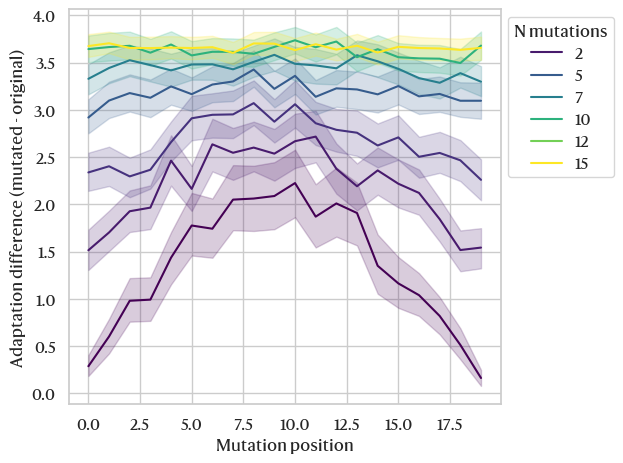

In [42]:
g = sns.lineplot(df_mutations[(df_mutations['Log sensitivity'] >= -1) & (df_mutations['Log precision'] >= 0)
                          & (df_mutations['N mutations'] > 0)],
                          x='mutation_positions_list', y='adaptation diffs',
                          hue='N mutations', palette=PALETTE, estimator='mean') #, errorbar='sd')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.xlabel('Mutation position')
plt.ylabel('Adaptation difference (mutated - original)')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_positions_adaptation_diffs.png'), 
            bbox_inches='tight', dpi=300)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for i, c in enumerate(['Log sensitivity', 'Log precision']):
    is_legend = (i == 1)
    g = sns.lineplot(df_mutations[(df_mutations['Log sensitivity'] >= -1) & (df_mutations['Log precision'] >= 0)
                          & (df_mutations['N mutations'] > 0)],
                          x='mutation_positions_list', y=f'{c} diffs',
                          hue='N mutations', palette=PALETTE, ax=axs[i],
                          legend=is_legend)
    if is_legend:
        sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    axs[i].set_xlabel('Mutation position')
    axs[i].set_ylabel(f'{c.capitalize()} difference (mutated - original)')
    axs[i].set_title(f'Change in {c.capitalize()} by mutation position')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_positions_sens_prec_diffs.png'), 
            bbox_inches='tight', dpi=300)

Now looking at strictly adaptable circuits

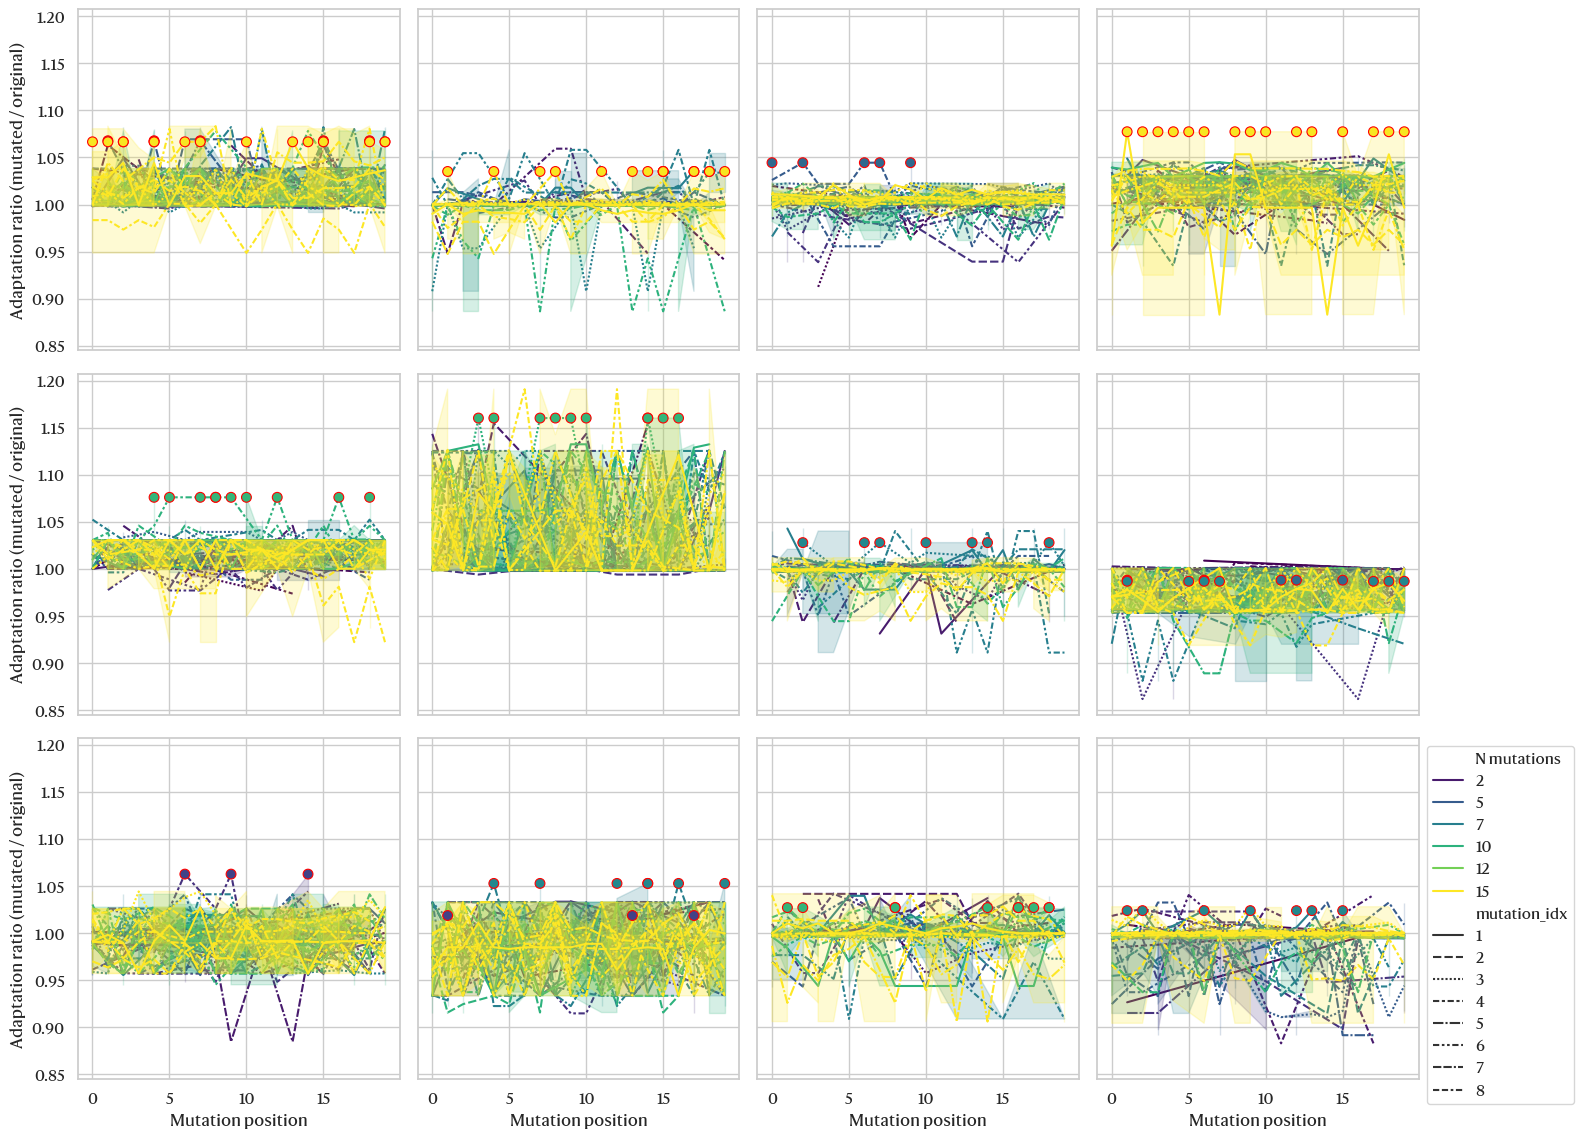

In [ ]:
circuits_adaptable = data[filt_samp & filt_adapt_strict]['circuit_name'].unique()
circuits_adaptable = circuits_adaptable[:12]

filt_muts_adapt = (df_mutations['Log sensitivity'] >= 0.) & (df_mutations['Log precision'] >= 1.0)

nrows = 3 # int(np.ceil(np.sqrt(len(circuits_adaptable))))
ncols = 4 # int(np.ceil(np.sqrt(len(circuits_adaptable))))
fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)

all_mutations = sorted(df_mutations['N mutations'].unique())
n = 100
colors_highres = sns.color_palette(PALETTE, n_colors=n) 
idxs_color = np.interp(all_mutations, [all_mutations[0], all_mutations[-1]], [0, n-1]).astype(int)
colors = [colors_highres[idxs_color[all_mutations.index(ii)]] for ii in all_mutations]
for i, circ in enumerate(circuits_adaptable):
    filt_muts_circ = df_mutations['circuit_name'] == circuits_adaptable[i]
    is_legend = i == len(circuits_adaptable) - 1
    g = sns.lineplot(df_mutations[filt_muts_circ & (df_mutations['N mutations'] > 0)],
                x='mutation_positions_list', y='adaptation ratio', 
                style='mutation_idx',
                hue='N mutations', palette=PALETTE,
                estimator='mean', ax=axs.flat[i], legend=is_legend,
                )
    if is_legend:
        sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    
    curr_mutations = df_mutations[filt_muts_circ & filt_muts_adapt]['N mutations'].unique()
    curr_colors = [colors[all_mutations.index(ii)] for ii in curr_mutations]
    gg = sns.scatterplot(df_mutations[filt_muts_circ & filt_muts_adapt],
                    x='mutation_positions_list', y='adaptation ratio', 
                    hue='N mutations', palette=curr_colors,
                    ax=axs.flat[i], legend=False, s=50) #, color='black', alpha=1.0)
    sc = axs.flat[i].collections[-1]
    sc.set_edgecolor('red')
    sc.set_linewidth(0.8)

    axs.flat[i].set_xlabel('Mutation position')
    axs.flat[i].set_ylabel('Adaptation ratio (mutated / original)')

    for artist in gg.lines:
        artist.set_zorder(10000)
    for artist in gg.collections:
        artist.set_zorder(10000)

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_position_adaptation_ratio.png'),
            bbox_inches='tight', dpi=300)


# Binding energies

In [ ]:
for k in x_cols:
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
x_cols_diffs = [f'{k} diffs' for k in x_cols]
x_cols_self_diffs = [f'{k} diffs' for k in x_cols_self]
x_cols_inter_diffs = [f'{k} diffs' for k in x_cols_inter]

In [ ]:
df_mutations = make_mutations_dataframe(data, filt_samp, filt_m, x_cols_diffs + x_cols + ['fold_change ratio', 'fold_change diffs'])

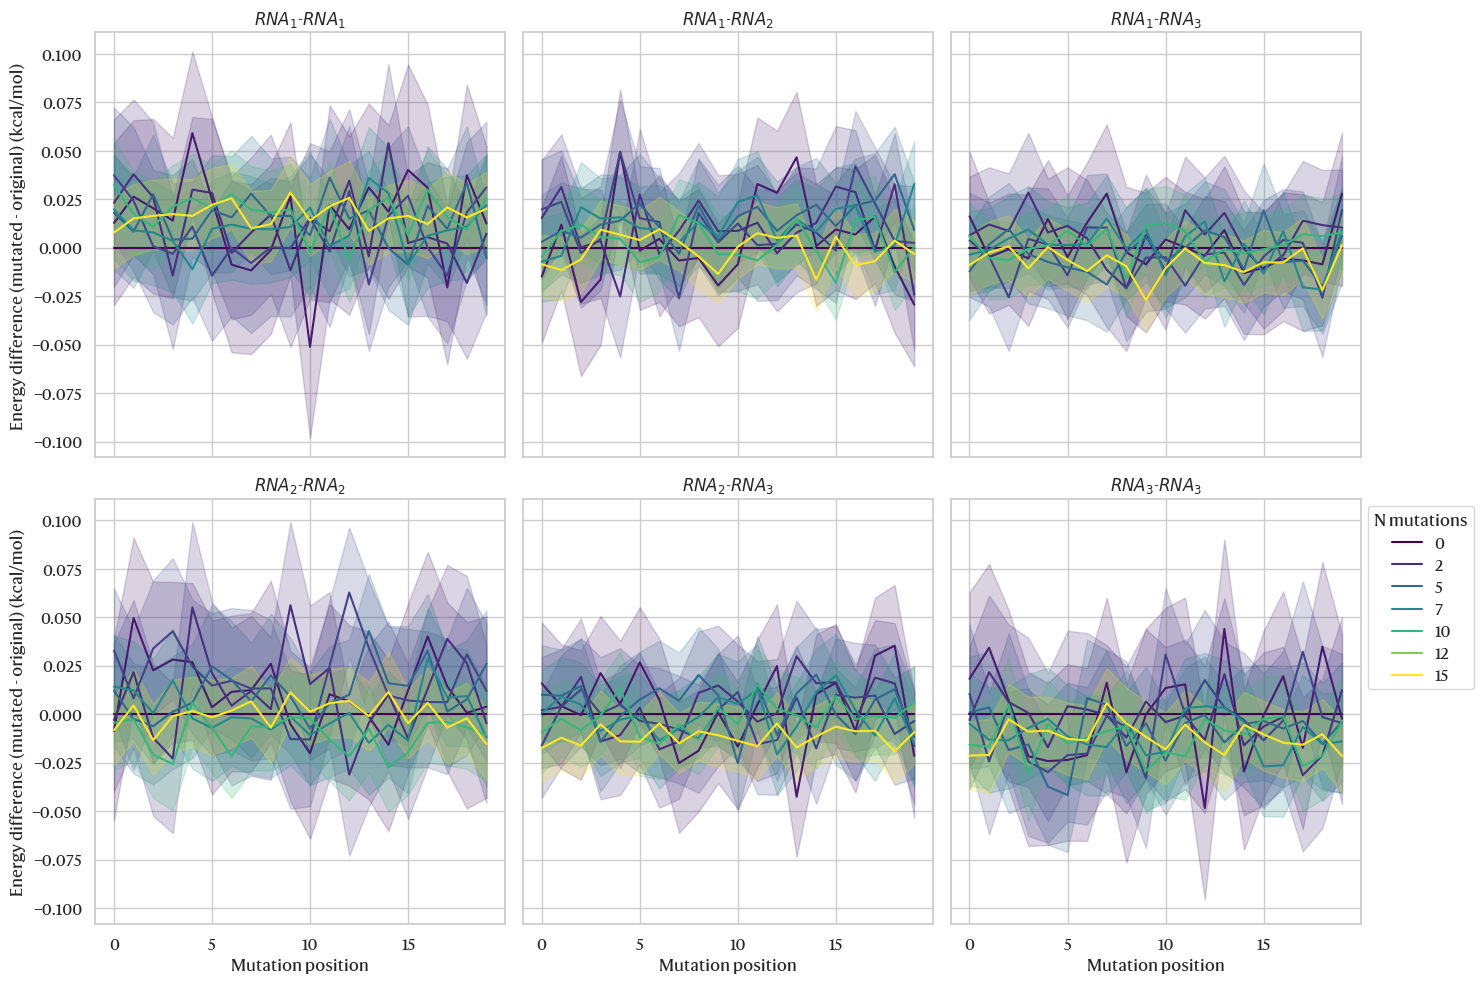

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(5*3, 5*2), sharex=True, sharey=True)
for i, (c, title) in enumerate(zip(x_cols_diffs, titles)):
    g = sns.lineplot(df_mutations, x='mutation_positions_list', y=c, 
             hue='N mutations', palette=PALETTE, ax=axs.flat[i], legend=i==5)
    axs.flat[i].set_xlabel('Mutation position')
    axs.flat[i].set_ylabel(f'Energy difference (mutated - original) (kcal/mol)')
    axs.flat[i].set_title(f'{title}')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_position_binding_energy.png'),
            bbox_inches='tight', dpi=300)

# Binding energies: null -> functional

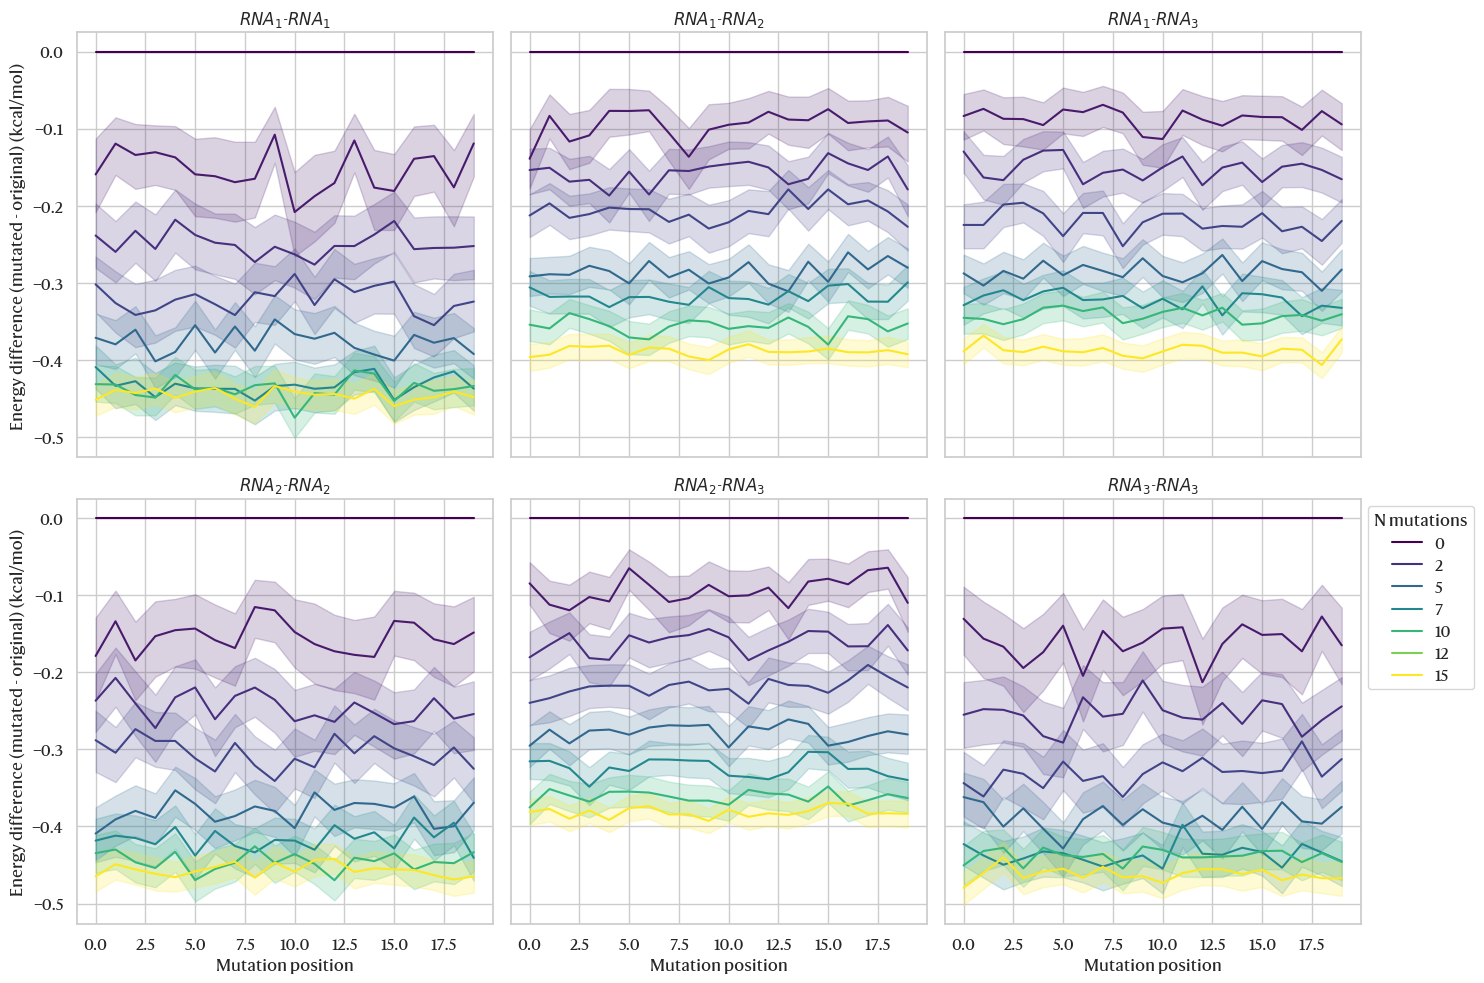

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(5*3, 5*2), sharex=True, sharey=True)
for i, (c, title) in enumerate(zip(x_cols_diffs, titles)):
    g = sns.lineplot(df_mutations[df_mutations['was_og_null']], x='mutation_positions_list', y=c, 
             hue='N mutations', palette=PALETTE, ax=axs.flat[i], legend=i==5)
    axs.flat[i].set_xlabel('Mutation position')
    axs.flat[i].set_ylabel(f'Energy difference (mutated - original) (kcal/mol)')
    axs.flat[i].set_title(f'{title}')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_position_binding_energy_nulls.png'),
            bbox_inches='tight', dpi=300)

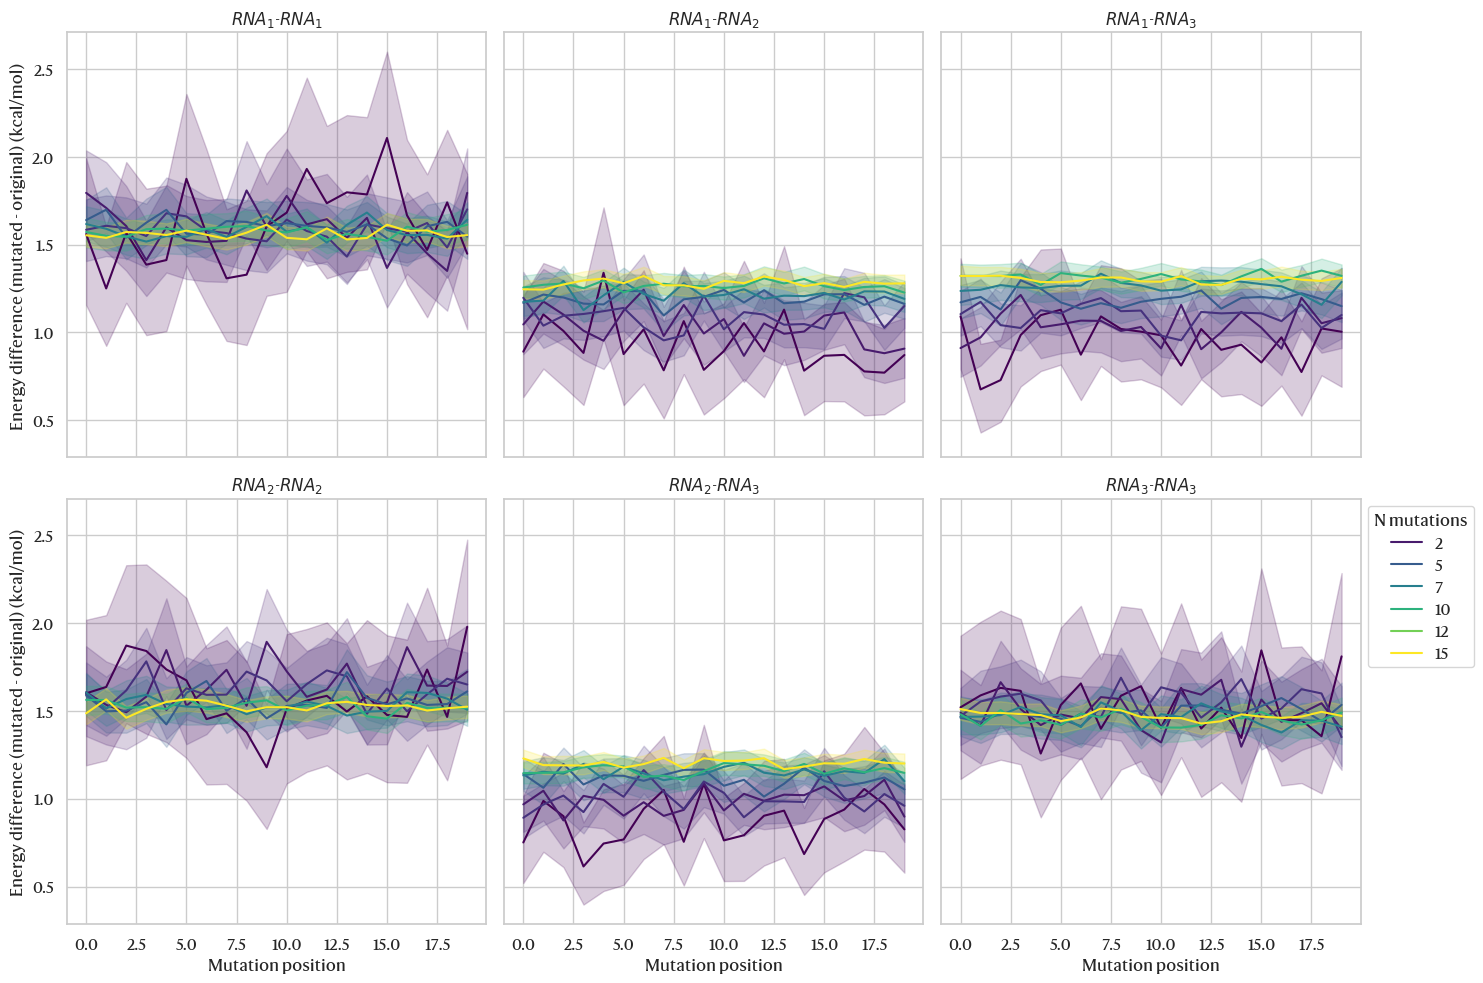

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(5*3, 5*2), sharex=True, sharey=True)
for i, (c, title) in enumerate(zip(x_cols_diffs, titles)):
    g = sns.lineplot(df_mutations[df_mutations['was_only_mut_null']], x='mutation_positions_list', y=c, 
             hue='N mutations', palette=PALETTE, ax=axs.flat[i], legend=i==5)
    axs.flat[i].set_xlabel('Mutation position')
    axs.flat[i].set_ylabel(f'Energy difference (mutated - original) (kcal/mol)')
    axs.flat[i].set_title(f'{title}')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'mutation_position_binding_energy_mutnulls.png'),
            bbox_inches='tight', dpi=300)

# Evolutionary landscape of adaptable circuits

In [ ]:
# filt_muts_circ = df_mutations['circuit_name'] == circuits_adaptable[i]
# df_mutations[filt_muts_circ & (df_mutations['N mutations'] > 0)]

# sns.scatterplot(data, 
#                 x='adaptation', y=data['adaptation diffs'] + data['adaptation'])